In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from model_structure import *

# 1. Setup Device and Model
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 4

# Pick an example model from your list (e.g., u_net_se)
# Note: Ensure your model classes (UNetSE, etc.) are defined in the notebook cells above this.
model = UNetBiPyramid(in_channels=4, num_classes=NUM_CLASSES, deep_supervision=True)
checkpoint_path = '/home/oil/Git-Repository/ImproveBrainTumorSegmentationModel/ignore_dir/TrainedWeight/U-Net_BiPyramid_best_checkpoint.pth' # Update this

# Load weights
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(DEVICE).eval()

# 2. Load and Preprocess .npy Data
def load_and_predict(npy_path, model, device):
    # Load .npy (Expected shape: [4, H, W] or [H, W, 4])
    data = np.load(npy_path)
    
    # Ensure shape is [Channels, H, W] for PyTorch
    if data.shape[-1] == 4:
        data = data.transpose(2, 0, 1)
        
    # Convert to tensor and add batch dimension [1, 4, H, W]
    input_tensor = torch.from_numpy(data).float().unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
        # Get the class with highest probability for each pixel
        prediction = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
        
    return data, prediction

# 3. Plotting with Overlay
def plot_prediction(image_data, pred_mask):
    # BraTS usually uses 4 channels: T1, T1ce, T2, FLAIR. 
    # We use the FLAIR channel (index 3) or T2 (index 2) as the background image.
    background = image_data[3] 
    
    # Define a custom colormap for classes (0: BG, 1: Necrotic, 2: Edema, 3: Enhancing)
    # Mapping colors: Transparent, Red, Green, Yellow
    colors = ['none', 'red', 'green', 'yellow']
    cmap = ListedColormap(colors)
    
    plt.figure(figsize=(12, 6))

    # Original Image (FLAIR)
    plt.subplot(1, 2, 1)
    plt.imshow(background, cmap='gray')
    plt.title("Original Image (FLAIR)")
    plt.axis('off')

    # Overlay: Image + Mask
    plt.subplot(1, 2, 2)
    plt.imshow(background, cmap='gray')
    # Use alpha to make the mask semi-transparent
    plt.imshow(pred_mask, cmap=cmap, alpha=0.4) 
    plt.title("Predicted Mask Overlay")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- EXECUTION ---
# npy_file = '/home/oil/Git-Repository/ImproveBrainTumorSegmentationModel/ignore_dir/test_data/BraTS-GLI-03031-100_s64.npy' # Update this
# img_data, mask = load_and_predict(npy_file, model, DEVICE)
# plot_prediction(img_data, mask)

## Low Grade


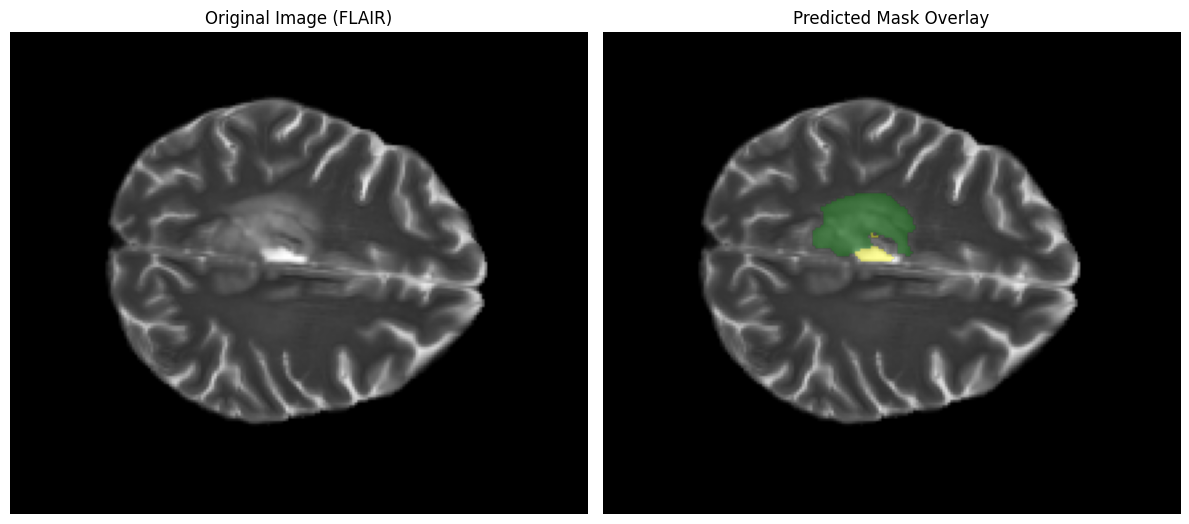

In [36]:
npy_file = '/home/oil/Git-Repository/ImproveBrainTumorSegmentationModel/ignore_dir/test_data/BraTS-GLI-02992-100_s122.npy' # Update this
img_data, mask = load_and_predict(npy_file, model, DEVICE)
plot_prediction(img_data, mask)

## HIGH Grade

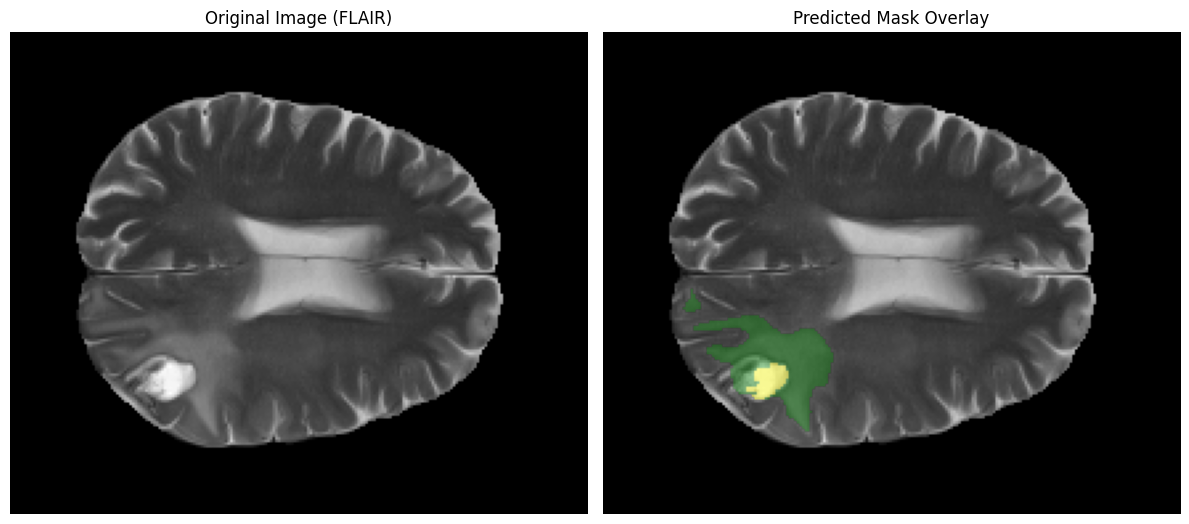

In [19]:
npy_file = '/home/oil/Git-Repository/ImproveBrainTumorSegmentationModel/ignore_dir/test_data/BraTS-GLI-03064-100_s104.npy' # Update this
img_data, mask = load_and_predict(npy_file, model, DEVICE)
plot_prediction(img_data, mask)

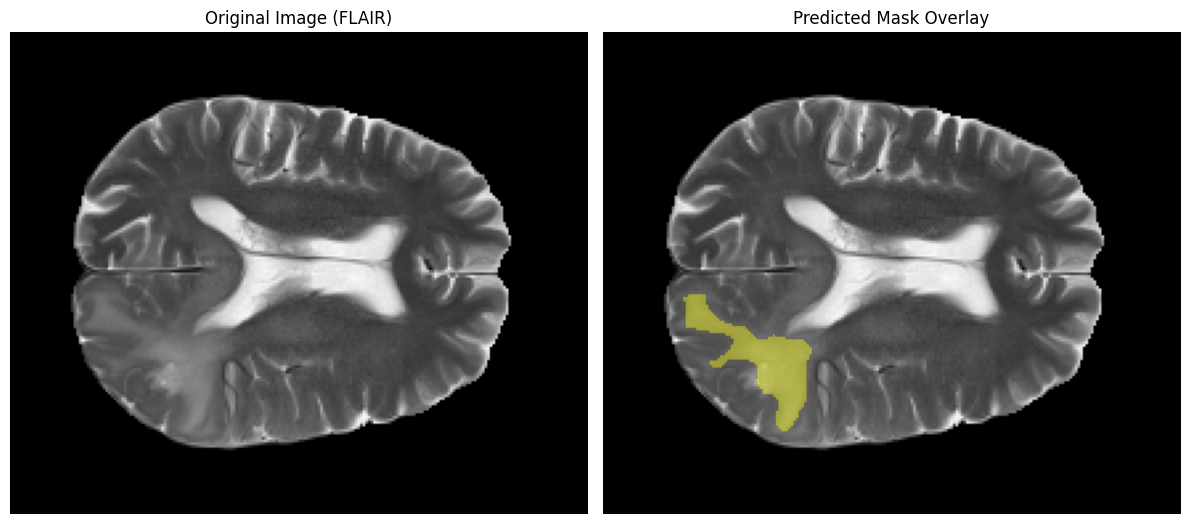

In [20]:
# BraTS-GLI-03064-100_s96.npy
npy_file = '/home/oil/Git-Repository/ImproveBrainTumorSegmentationModel/ignore_dir/test_data/BraTS-GLI-03064-100_s96.npy' # Update this
img_data, mask = load_and_predict(npy_file, model, DEVICE)
plot_prediction(img_data, mask)